In [2]:
import os
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import os
import pandas as pd
import numpy as np
import random
import logging

In [4]:
reacoes = pd.read_csv("dados_reacoes.csv")
random.seed(42)
random.shuffle(reacoes)
reacoes

KeyError: 1340975

In [4]:
import json

# .CORREÇÃO DO SORTEIO
total_moleculas = len(all_smiles_raw)
logger.info(f"Total de moléculas limpas: {total_moleculas}")

# Definimos 90% para treino e 10% para validação
n_train = int(total_moleculas * 0.9)

train_smiles = all_smiles_raw[:n_train]
val_smiles = all_smiles_raw[n_train:]

# Verificação de segurança para o Colab não travar
if len(val_smiles) == 0:
    logger.error("ERRO: O dataset de validação está vazio! Verifique se os arquivos foram carregados corretamente.")
else:
    logger.info(f"Sorteio concluído. Treino: {len(train_smiles)} | Validação: {len(val_smiles)}")


logger.info(f"Sorteio concluído. Treino: {len(train_smiles)} | Validação: {len(val_smiles)}")

# Vocabulário e Encoding
vocab = sorted(list(set("".join(train_smiles + val_smiles))))
char_to_idx = {ch: i + 1 for i, ch in enumerate(vocab)}
char_to_idx['<PAD>'] = 0
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
vocab_size = len(char_to_idx)
max_len = 512

def encode(s_list):
    res = []
    for s in s_list:
        t = [char_to_idx.get(c, 0) for c in s[:max_len]]
        res.append(t + [0]*(max_len - len(t)))
    return np.array(res, dtype=np.int32)

# SÓ RODE ISSO UMA VEZ NA VIDA:
vocab = sorted(list(set("".join(dataset_limpo))))
char_to_idx = {ch: i + 1 for i, ch in enumerate(vocab)}
char_to_idx['<PAD>'] = 0

# SALVE ISSO IMEDIATAMENTE
with open("vocab_oficial.json", "w") as f:
    json.dump(char_to_idx, f)

# Agora o encoding deve funcionar sem o erro de índice
x_t_enc = encode(train_smiles)
x_v_enc = encode(val_smiles)

X_train, Y_train = x_t_enc[:, :-1], x_t_enc[:, 1:]
X_val, Y_val = x_v_enc[:, :-1], x_v_enc[:, 1:]# Agora o encoding deve funcionar sem o erro de índice


INFO: Total de moléculas limpas: 1484442
INFO: Sorteio concluído. Treino: 1335997 | Validação: 148445
INFO: Sorteio concluído. Treino: 1335997 | Validação: 148445


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def get_causal_mask(size):
    """Gera máscara causal que funciona via broadcasting (sem erro de KerasTensor)"""
    i = tf.range(size)[:, None]
    j = tf.range(size)
    mask = tf.cast(i >= j, tf.int32)
    return tf.reshape(mask, (1, size, size))

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim)])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, mask):
        # A máscara entra aqui e é aplicada no Self-Attention
        attn_output = self.att(inputs, inputs, attention_mask=mask)
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(inputs + attn_output)
        return self.layernorm2(out1 + self.dropout2(self.ffn(out1)))

# Construção do Modelo Funcional
max_len = 512
embed_dim = 128
seq_len = max_len - 1

inputs = layers.Input(shape=(seq_len,))
# Embedding de conteúdo + Posicional
x = layers.Embedding(vocab_size, embed_dim)(inputs)
pos_indices = tf.range(start=0, limit=seq_len, delta=1)
x += layers.Embedding(seq_len, embed_dim)(pos_indices)

# Criamos a máscara UMA VEZ. O Keras entende o broadcast para o batch.
mask = get_causal_mask(seq_len)

# Adicionamos os blocos Transformer (MolGPT utiliza 4 camadas no seu PDF)
for _ in range(4):
    x = TransformerBlock(embed_dim, 8, 512)(x, mask)

outputs = layers.Dense(vocab_size, activation="softmax")(x)
# No Colab, use um Learning Rate MENOR e adicione Clipnorm
opt = tf.keras.optimizers.Adam(
    learning_rate=0.0001, # Reduzi de 0.001 para 0.0001
    clipnorm=1.0          # ISSO É VITAL: Impede que o gradiente "exploda"
)

# Crie um array de pesos do tamanho do seu vocabulário
weights = np.ones(vocab_size, dtype='float32')

# 1. Penalidade quase ZERO para o Padding (índice 0)
# Isso faz o modelo parar de ganhar 'pontos fáceis' prevendo o vazio
weights[0] = 0.01

# 2. Penalidade ALTA para todos os átomos reais (Importante para mecanismos!)
# 'l' é a parte minúscula do Cloro, 'r' do Bromo
for char in ['C', 'H', 'N', 'O', 'P', 'S', 'F', 'I', 'B', 'l', 'r']:
    if char in char_to_idx:
        weights[char_to_idx[char]] = 20.0

# Penalidade ALTA para símbolos estruturais de REAÇÃO e intermediários
for char in ['[', ']', '=', '>', '.', '+', '-']:
    if char in char_to_idx:
        weights[char_to_idx[char]] = 15.0 # Aumentei um pouco para evitar gagueira de colchetes

# 3. Penalidade MÉDIA para números, ramificações e quiralidade
for char in ['1', '2', '3', '4', '5', '6', '7', '8', '9', '@', '(', ')', '/', '\\']:
    if char in char_to_idx:
        weights[char_to_idx[char]] = 5.0

def weighted_masked_loss(y_true, y_pred):
    # Calcula o loss normal para cada caractere
    loss_fcn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction='none')
    loss = loss_fcn(y_true, y_pred)

    # Aplica os pesos baseados no caractere real (y_true)
    # tf.gather busca o peso definido acima para cada token
    batch_weights = tf.gather(weights, tf.cast(y_true, tf.int32))

    # Multiplica o erro pelo peso de importância
    weighted_loss = loss * batch_weights

    return tf.reduce_mean(weighted_loss)

# Métrica de acurácia que IGNORE o padding (Acurácia Real)
def masked_accuracy(y_true, y_pred):
    mask = tf.math.logical_not(tf.math.equal(y_true, 0))
    acc = tf.keras.metrics.sparse_categorical_accuracy(y_true, y_pred)
    mask = tf.cast(mask, tf.float32)
    acc *= mask
    return tf.reduce_sum(acc) / tf.reduce_sum(mask)

model = Model(inputs=inputs, outputs=outputs)
opt = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)

model.compile(
    optimizer=opt,
    loss=weighted_masked_loss, # Usa a penalidade pesada
    metrics=[masked_accuracy]   # Usa a métrica que ignora o vazio
)
logger.info("Modelo MolGPT construído e compilado sem erros.")

INFO: Modelo MolGPT construído e compilado sem erros.


In [12]:
import json
import tensorflow as tf

# 1. DEFINIR O CALLBACK DE SALVAMENTO (Salva a cada época)
# O arquivo terá o número da época no nome, ex: molgpt_uspto_ep01.weights.h5
checkpoint_path = "molgpt_uspto_ep{epoch:02d}.weights.h5"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,   # Salva apenas os pesos conforme seu padrão
    verbose=1                 # Avisa no log quando salvar
)

# 2. TREINAMENTO COM O CALLBACK
# Adicionamos o parâmetro 'callbacks'
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=5, 
    batch_size=128,
    callbacks=[checkpoint_callback] # <--- O segredo está aqui
)

# 3. SALVAMENTO FINAL (Para garantir a última versão)
model.save_weights("molgpt_uspto_final.weights.h5")
logger.info("Modelo final salvo como molgpt_uspto_final.weights.h5")

# 4. SALVAR O VOCABULÁRIO (Mesma lógica de antes)
vocab_data = {
    "char_to_idx": char_to_idx,
    "idx_to_char": idx_to_char,
    "max_len": max_len,
    "vocab_size": vocab_size
}
with open("molgpt_vocab.json", "w") as f:
    json.dump(vocab_data, f)
logger.info("Vocabulário salvo. Motor pronto para integração!")

Epoch 1/5
10438/10438 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - loss: 6.4163 - masked_accuracy: 0.6466
Epoch 1: saving model to molgpt_uspto_ep01.weights.h5

Epoch 1: finished saving model to molgpt_uspto_ep01.weights.h5
10438/10438 ━━━━━━━━━━━━━━━━━━━━ 5490s 524ms/step - loss: 4.8390 - masked_accuracy: 0.7205 - val_loss: 3.1953 - val_masked_accuracy: 0.8175
Epoch 2/5
10438/10438 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - loss: 3.2185 - masked_accuracy: 0.8173
Epoch 2: saving model to molgpt_uspto_ep02.weights.h5

Epoch 2: finished saving model to molgpt_uspto_ep02.weights.h5
10438/10438 ━━━━━━━━━━━━━━━━━━━━ 5452s 522ms/step - loss: 2.9996 - masked_accuracy: 0.8327 - val_loss: 2.3654 - val_masked_accuracy: 0.8763
Epoch 3/5
10438/10438 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - loss: 2.4958 - masked_accuracy: 0.8689
Epoch 3: saving model to molgpt_uspto_ep03.weights.h5

Epoch 3: finished saving model to molgpt_uspto_ep03.weights.h5
10438/10438 ━━━━━━━━━━━━━━━━━━━━ 5453s 522ms/step - loss: 2.4164 - maske

INFO: Modelo final salvo como molgpt_uspto_final.weights.h5
INFO: Vocabulário salvo. Motor pronto para integração!


DEBUG: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG: findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG: findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG: findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG: findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu S

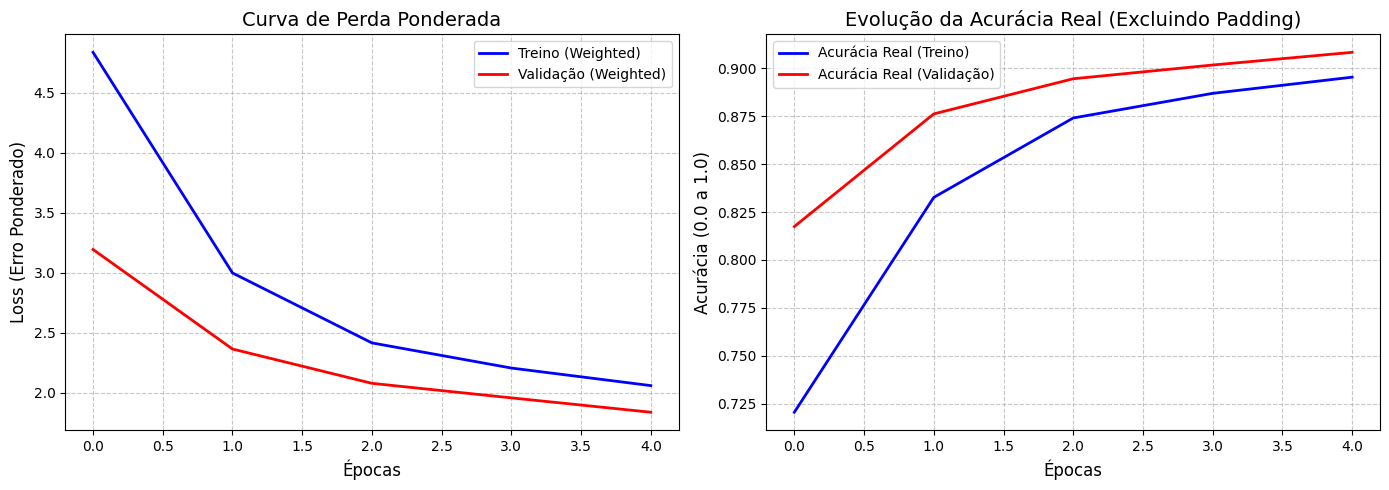

Gráficos gerados. A acurácia de validação final foi de: 90.84%


In [13]:
import matplotlib.pyplot as plt

# Configuração do estilo visual profissional
plt.figure(figsize=(14, 5))

# 1. Gráfico da Função de Loss Ponderada
# Mostra como a penalidade sobre os erros químicos diminuiu
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino (Weighted)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validação (Weighted)', color='red', linewidth=2)
plt.title('Curva de Perda Ponderada', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss (Erro Ponderado)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 2. Gráfico de Acurácia Real (Masked)
# Este é o gráfico que prova que o modelo aprendeu SMILES, não Padding
plt.subplot(1, 2, 2)
# Nota: Usamos as chaves 'masked_accuracy' que definimos no model.compile
plt.plot(history.history['masked_accuracy'], label='Acurácia Real (Treino)', color='blue', linewidth=2)
plt.plot(history.history['val_masked_accuracy'], label='Acurácia Real (Validação)', color='red', linewidth=2)
plt.title('Evolução da Acurácia Real (Excluindo Padding)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Acurácia (0.0 a 1.0)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()

# Salvar o gráfico com nome técnico para o relatório
plt.savefig("validacao_tecnica_molgpt.png", dpi=300)
plt.show()

print("Gráficos gerados. A acurácia de validação final foi de: {:.2f}%".format(history.history['val_masked_accuracy'][-1] * 100))

In [2]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Configurações PGF para integração perfeita com LaTeX
mpl.use("pgf")
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
    "font.size": 11,               # Tamanho padrão IEEE
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pgf.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{mathtools}
    """
})

epochs = [1, 2, 3, 4, 5]

data_loss = {
    'epoch': epochs,
    'train': [4.8390, 2.9996, 2.4164, 2.2068, 2.0604],
    'val':   [3.1953, 2.3654, 2.0794, 1.9581, 1.8384]
}

data_acc = {
    'epoch': epochs,
    'train': [0.7205, 0.8327, 0.8741, 0.8870, 0.8954],
    'val':   [0.8175, 0.8763, 0.8946, 0.9018, 0.9084]
}

def export_plot_pgf(df, x_col, y_cols, labels, title, ylabel, output_name, color=['b', 'r']):
    """
    Gera um gráfico PGF seguindo as proporções de coluna única.
    """
    # Proporção 3.3 x 2.5 polegadas é ideal para colunas de 8.8cm (IEEE)
    plt.figure(figsize=(3.3, 2.5))
    
    for y, label, col in zip(y_cols, labels, color):
        plt.plot(df[x_col], df[y], color=col, label=label, linewidth=1.5)
    
    plt.title(title, fontsize=11)
    plt.xlabel('Épocas')
    plt.ylabel(ylabel)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # Ajuste de margens para não cortar labels
    plt.savefig(output_name, bbox_inches='tight')
    plt.close()

# Execução da geração dos arquivos

# 1. Gráfico de Perda (Loss)
df_loss = pd.DataFrame(data_loss)
export_plot_pgf(
    df=df_loss, 
    x_col='epoch', 
    y_cols=['train', 'val'], 
    labels=['Treino (Weighted)', 'Validação (Weighted)'],
    title='Curva de Perda Ponderada',
    ylabel='Loss (Erro Ponderado)',
    output_name='loss_curve.pgf'
)

# 2. Gráfico de Acurácia
df_acc = pd.DataFrame(data_acc)
export_plot_pgf(
    df=df_acc, 
    x_col='epoch', 
    y_cols=['train', 'val'], 
    labels=['Acurácia Real (Treino)', 'Acurácia Real (Validação)'],
    title='Evolução da Acurácia Real',
    ylabel='Acurácia (0.0 a 1.0)',
    output_name='acc_curve.pgf'
)

print("Arquivos PGF gerados com sucesso: loss_curve.pgf e acc_curve.pgf")

Arquivos PGF gerados com sucesso: loss_curve.pgf e acc_curve.pgf


In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

def generate(model, n=20):
    results = []
    for _ in range(n):
        # Semente: átomo de Carbono 'C'
        seq = [char_to_idx.get('C', 1)]
        for _ in range(seq_len - 1):
            cur_input = np.array([seq + [0]*(seq_len - len(seq))])
            p = model.predict(cur_input, verbose=0)[0][len(seq)-1]
            token = np.random.choice(len(p), p=p)
            if token == 0: break
            seq.append(token)
        results.append("".join([idx_to_char.get(i, '') for i in seq]))
    return results

logger.info("Amostrando moléculas geradas...")
gen_smiles = generate(model_recarregado)
mols = [Chem.MolFromSmiles(s) for s in gen_smiles]
valid_mols = [m for m in mols if m is not None]

logger.info(f"Validez: {len(valid_mols)}/{len(gen_smiles)}")
Draw.MolsToGridImage(valid_mols, molsPerRow=5, useSVG=True) if valid_mols else print("Nenhuma válida.")

INFO: Amostrando moléculas geradas...
[11:29:42] SMILES Parse Error: syntax error while parsing: @B4HB37N633322
[11:29:42] SMILES Parse Error: check for mistakes around position 1:
[11:29:42] @B4HB37N633322
[11:29:42] ^
[11:29:42] SMILES Parse Error: Failed parsing SMILES '@B4HB37N633322' for input: '@B4HB37N633322'
[11:29:42] SMILES Parse Error: syntax error while parsing: @6BA
[11:29:42] SMILES Parse Error: check for mistakes around position 1:
[11:29:42] @6BA
[11:29:42] ^
[11:29:42] SMILES Parse Error: Failed parsing SMILES '@6BA' for input: '@6BA'
[11:29:42] SMILES Parse Error: syntax error while parsing: @
[11:29:42] SMILES Parse Error: check for mistakes around position 1:
[11:29:42] @
[11:29:42] ^
[11:29:42] SMILES Parse Error: Failed parsing SMILES '@' for input: '@'
[11:29:42] SMILES Parse Error: syntax error while parsing: @
[11:29:42] SMILES Parse Error: check for mistakes around position 1:
[11:29:42] @
[11:29:42] ^
[11:29:42] SMILES Parse Error: Failed parsing SMILES '@' f

Nenhuma válida.
